# 1 - Exploración del Dataset PlantVillage
Análisis inicial del dataset: clases, distribución de imágenes y visualización de ejemplos.

2 — Imports

Esto instala las librerías en el entorno de Colab.
-q significa "quiet": instala sin mostrar tanto texto


In [1]:
%pip install torch torchvision matplotlib seaborn scikit-learn tqdm Pillow -q

Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import torch              # el framework de deep learning que usaremos
import torchvision        # extensión de torch para trabajar con imágenes
import matplotlib.pyplot as plt   # para hacer gráficas (plt es el alias estándar)
import seaborn as sns             # gráficas bonitas (sns es el alias estándar)
from sklearn.metrics import confusion_matrix  # para evaluar el modelo más adelante
from tqdm import tqdm             # barra de progreso cuando entrenamos
from PIL import Image             # para abrir y manipular imágenes
import os                         # para navegar en las carpetas
import random                     # para elegir imágenes al azar

print("Todo instalado correctamente")
print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")

Todo instalado correctamente
PyTorch version: 2.11.0+cpu
Torchvision version: 0.26.0+cpu


3 — Configuración del dataset

In [ ]:
import os

# Ruta local del dataset
DATASET_PATH = os.path.join(os.getcwd(), "plantvillage dataset", "color")

if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(f"Dataset no encontrado en: {DATASET_PATH}
"
                            f"Descargalo de Kaggle y ponlo en: {os.getcwd()}")

clases = sorted(os.listdir(DATASET_PATH))
print(f"Total de clases: {len(clases)}")


4 — Conteo de imágenes por clase

In [ ]:
# crea un diccionario, por cada {clase : cantidad de imagenes}
conteo = {
    clase: len(os.listdir(os.path.join(DATASET_PATH, clase)))
    for clase in clases
}

total = sum(conteo.values())
print(f"Total de imágenes: {total:,}")
print(f"Promedio por clase: {total // len(clases)}")

Total de imágenes: 54,305
Promedio por clase: 1429


5 — Gráfica de distribución

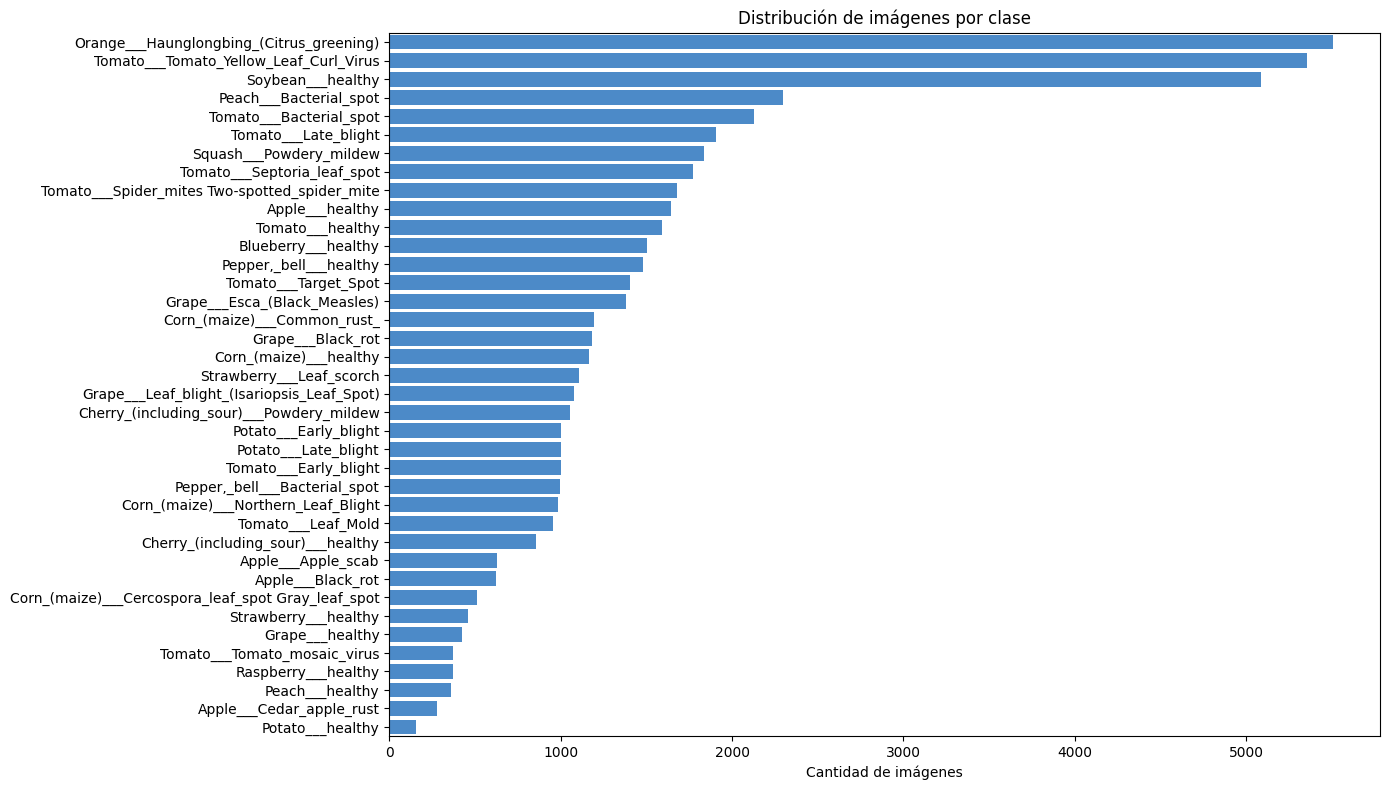

In [ ]:
# ordena el diccionario por el valor
#.items devuelve pares (clave: valor)
# key=lambda x: x[1] ordena por el valor de la posición 1
# reverse=True = de mayor a menor
conteo_ordenado = dict(sorted(conteo.items(), key=lambda x: x[1], reverse=True))

plt.figure(figsize=(14, 8)) # tamaño del lienzo: 14 ancho x 8 alto (en pulgadas)
sns.barplot(
    x=list(conteo_ordenado.values()), # eje X: cantidades
    y=list(conteo_ordenado.keys()),  # eje Y: nombres de clases
    color="#378ADD"   # color azul
    )
plt.title("Distribución de imágenes por clase")
plt.xlabel("Cantidad de imágenes")
plt.tight_layout() # ajusta márgenes automáticamente
plt.show() # renderiza la gráfica

6 — Visualización de ejemplos

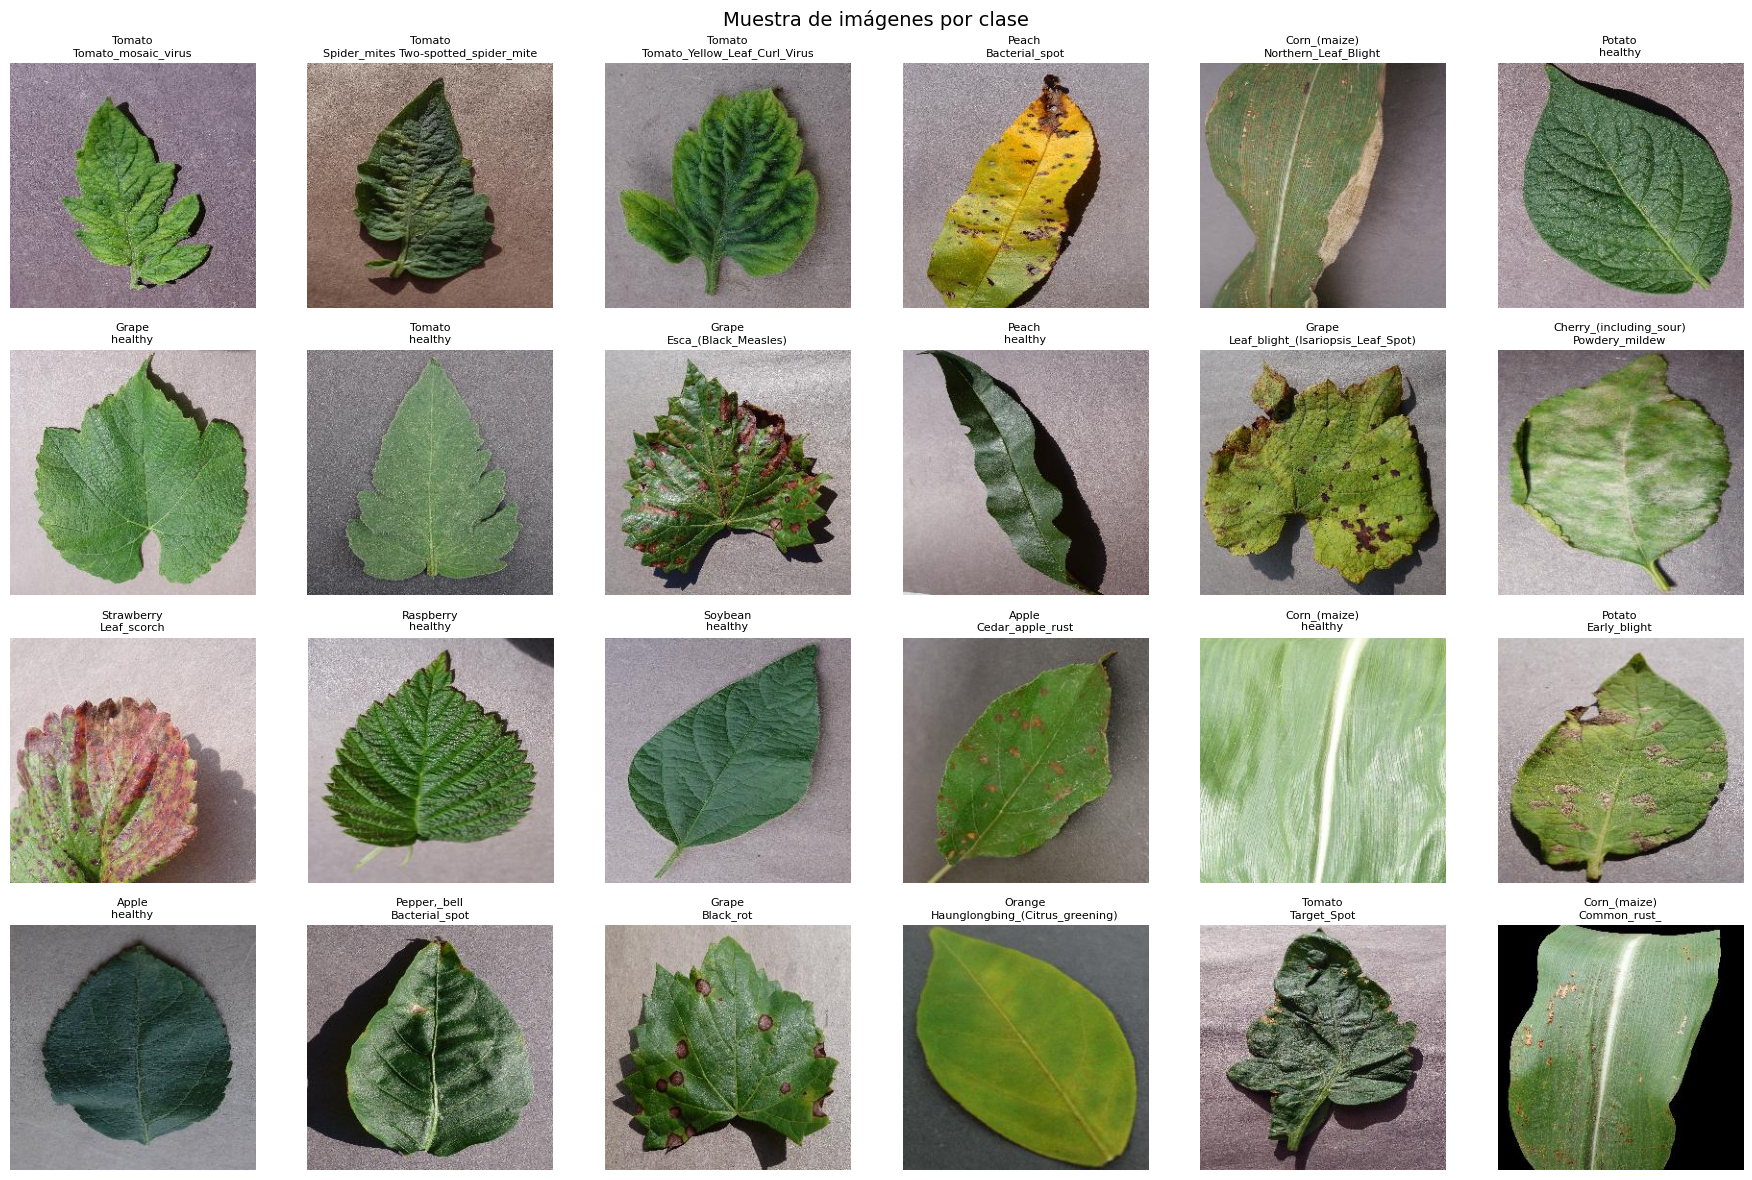

In [ ]:
# crea una cuadrícula de 4 filas x 6 columnas = 24 subgráficas
fig, axes = plt.subplots(4, 6, figsize=(18, 12))
axes = axes.flatten() # convierte la cuadrícula 2D en una lista 1D, más fácil de recorrer

muestra = random.sample(clases, 24) # elige 24 clases al azar (sin repetir)

for i, clase in enumerate(muestra): # enumerate devuelve el índice (i) y el valor (clase)
    clase_path = os.path.join(DATASET_PATH, clase) # devuelve la ruta de la clase
    img_file = random.choice(os.listdir(clase_path)) # elige una imagen al azar
    img = Image.open(os.path.join(clase_path, img_file)) #abrimos

    axes[i].imshow(img) # muestra la imagen en su subgráfica
    axes[i].set_title(clase.replace("___", "\n"), fontsize=8)
    axes[i].axis("off") # oculta los ejes x e y

plt.suptitle("Muestra de imágenes por clase", fontsize=14)
plt.tight_layout()
plt.show()